# Delayed-Planning meta-control — CBM model fitting (Revision 1)

**What this notebook does.** It re-fits the meta-control model space of the
delayed-planning task using the **Computational & Behavioural Modelling toolbox
(CBM; Piray et al., 2019, *PLoS Comput Biol*)** machinery — the Python port
[`cbm_python`](https://github.com/payampiray/cbm_python) — in place of the
in-house hierarchical Expectation–Maximisation procedure in `model_fitting.py`.

Two fitting routes are provided:

* **Fast MAP** (`run_map.py`, used by default here): each subject is fit by
  per-subject MAP (penalised maximum likelihood, weak Gaussian prior),
  parallelised across cores, with MBMC warm-started from its per-subject EM fit.
  The model comparison is **ΔBIC vs MBMC** (the quantity Reviewer 1 requested),
  with BIC = −2·loglik(MAP) + k·ln(n_obs).
* **Full CBM** (`run_cbm.py`, optional): `cbm_lap` Laplace model evidence +
  `cbm_hbi` hierarchical Bayesian model comparison (model frequencies and
  protected exceedance probabilities). Slower; section 4 renders its output if
  present.

**Why.** Reviewer 1 (points 7–8) asked us to compare our model (MBMC) against a
meta-controller that reads goal-reachability off a **successor-representation
(SR)**–like quantity formed *offline, before the planning phase*, with the
simple rule *"if both actions reach the goal about equally, relinquish / don't
plan."* We implement that SR controller and a **predecessor-representation (PR;
Sharp & Eldar, 2024)** variant (backward replay from the goal), and compare them
to the winning **MBMC (Cache-MC + Replan)** model and a **control-bias-only**
baseline, **in both studies**.

## The models

| Model | Params | Idea |
|---|---|---|
| **MBMC** | 9 | Winning model. Bounded in-trial sampling of goal-reachability + caching/forgetting of resolved control choices + control bias. Produces learning dynamics. |
| **SR** | 2 | *Offline* successor representation: forward goal reachability ρ^SR(a) = P(reach goal \| heading to a). Log-odds of taking control = β·(reachability gap) + CB. **Static across trials** — no learning. |
| **PR** | 2 | *Offline* predecessor representation — the **retrospective posterior** P(originated via action a \| goal reached) = ρ^SR(a)/Σρ^SR, the Bayes inverse of the SR (Sharp & Eldar, 2024). Same decision rule. **Static.** |
| **CB** | 1 | Control-bias-only baseline: fixed P(take) at every decision. |

The SR/PR controllers use the fully-identified 2-parameter form: a slope **β**
on the successor/predecessor reachability *gap* between the two actions (the
reviewer's heuristic — take when the gap is large, relinquish when the two
actions reach the goal equally) plus a control bias **CB**. The representation
discount is fixed (γ = 1), so "reachability" is exactly *the probability of
reaching the goal* — the quantity the reviewer named.

Both SR and PR engage control via a map formed **before** the planning phase, so
they cannot reproduce the trial-by-trial improvement in adaptively-delayed
planning — the empirical signature MBMC captures via limited in-trial sampling.
This notebook quantifies how much worse they fit (ΔBIC / Δlog-evidence /
exceedance probability).


In [1]:
import os, sys, pickle, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')
sns.set(style='whitegrid', font_scale=1.15)
HERE = os.getcwd()
RES = os.path.join(HERE, 'results')
sys.path.insert(0, HERE)
import cbm_models as M
MODELS = M.build_models()
MODEL_ORDER = ['MBMC', 'SR', 'PR', 'CB']
PALETTE = {'MBMC':'#2c7fb8','SR':'#d95f0e','PR':'#cc4c02','CB':'#969696'}
print('models:', {k: v['npar'] for k, v in MODELS.items()})

models: {'MBMC': 9, 'SR': 2, 'PR': 2, 'CB': 1}


## 1. How the SR and PR meta-controllers read the task graph

At each decision the controller compares the goal-reachability of the two real
children (left/right). The map is computed **once, offline**:

* **SR** = forward occupancy under a random policy: *P(a random walk from this
  child reaches the goal landmark)*. With discount γ→1 this equals the
  random-policy reachability counts used inside MBMC.
* **PR** = the *predecessor / retrospective* representation (Sharp & Eldar, 2024):
  the probability that a goal-reaching trajectory **originated via** each action,
  `P(action a | goal reached) = ρ^SR(a) / Σ_a ρ^SR(a)` — the Bayes inverse of the
  SR. (On this task graph this coincides numerically with a reverse-random-walk
  occupancy seeded at the goal, but it is computed as the posterior by
  definition.)

When the two children reach the goal **equally**, taking control buys nothing on
the goal, so the relinquish bonus wins → **relinquish**. When only one child
reaches the goal, taking control secures it → **take**. This is exactly the
heuristic Reviewer 1 proposed.

The table below shows the reachability of the two `start` children for each goal
(= each *required planning depth*). Note SR and PR both correctly imply
*relinquish-at-start* for the shallow goals (equal children) and
*take-at-start* for the deep goal (cat), but differ in gradedness.

In [2]:
rows = []
fwd = M._reach_table(1.0)                       # forward SR reachability
for kind in ['SR', 'PR']:
    for depth, goal in M.DEPTH_TO_GOAL.items():
        c1, c2 = M.REAL_TRANSITIONS['start']
        v1, v2 = M._child_readout(kind, fwd[goal][c1], fwd[goal][c2])  # SR reach / PR posterior
        rows.append(dict(representation=kind, required_depth=depth, goal=goal,
                         val_toothbrush=round(v1, 3), val_baby=round(v2, 3),
                         gap=round(abs(v1 - v2) / 2, 3),
                         implied='take' if abs(v1 - v2) > 1e-9 else 'relinquish'))
reach_df = pd.DataFrame(rows).sort_values(['representation','required_depth'], ascending=[True,False])
reach_df

,representation,required_depth,goal,val_toothbrush,val_baby,gap,implied
3,PR,3,cat,1.00,0.00,0.500,take
4,PR,2,zebra,0.50,0.50,0.000,relinquish
5,PR,1,lamp,0.50,0.50,0.000,relinquish
0,SR,3,cat,0.25,0.00,0.125,take
1,SR,2,zebra,0.25,0.25,0.000,relinquish
2,SR,1,lamp,0.50,0.50,0.000,relinquish


## 2. Load CBM fit results

Fits are produced by `run_cbm.py` (run once per study, see the README). Here we
load the saved per-subject fits, the group comparison tables, and — if present —
the HBI summaries.

In [3]:
def load_results(study):
    fits = pd.read_csv(os.path.join(RES, f'fits_{study}.csv'))
    grp  = pd.read_csv(os.path.join(RES, f'group_{study}.csv'))
    hbi_path = os.path.join(RES, f'hbi_summary_{study}.pkl')
    hbi = pickle.load(open(hbi_path, 'rb')) if os.path.exists(hbi_path) else None
    return fits, grp, hbi

STUDIES = ['study1', 'study2']
data = {}
for st in STUDIES:
    try:
        data[st] = load_results(st)
        f, g, h = data[st]
        print(f'{st}: {f["sub"].nunique()} subjects, models={list(g.sort_values("sum_bic")["model"])}, '
              f'HBI={"yes" if h else "no"}')
    except FileNotFoundError as e:
        print(f'{st}: results not found — run `python run_cbm.py {st}` first ({e})')

study1: 93 subjects, models=['MBMC', 'SR', 'PR', 'CB'], HBI=no
study2: 163 subjects, models=['MBMC', 'SR', 'PR', 'CB'], HBI=no


## 3. Group model comparison — ΔBIC vs MBMC

The headline number for the response letter: **how much worse the offline SR /
PR meta-controllers fit than MBMC** (summed over subjects). ΔBIC > 0 means worse
than MBMC. (Also shown: summed Laplace log-model-evidence relative to MBMC.)

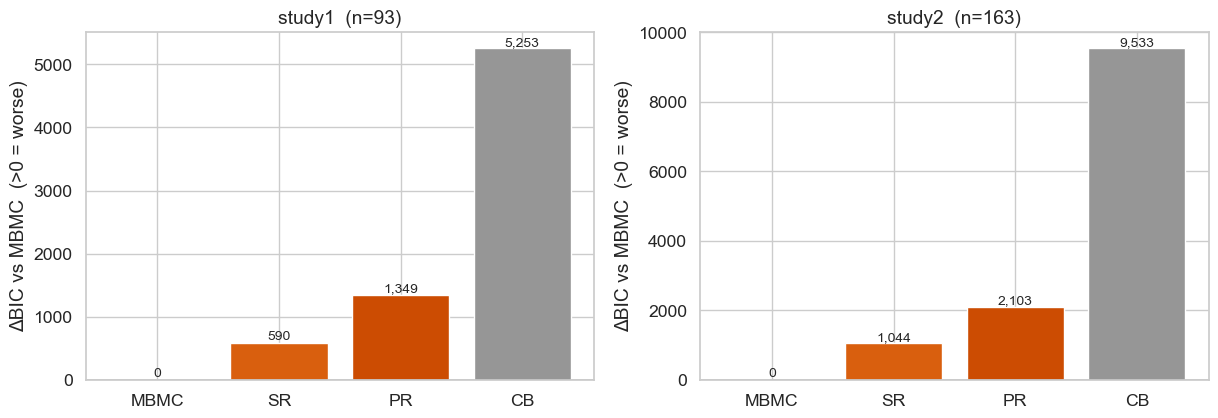

,study,model,npar,sum_loglik,sum_bic,dBIC_vs_MBMC,dLME_vs_MBMC
0,study1,MBMC,9,-2571.4,9489.2,0.0,0.0
1,study1,SR,2,-4556.5,10078.9,589.7,-1985.2
2,study1,PR,2,-4936.0,10838.0,1348.7,-2364.7
3,study1,CB,1,-7129.9,14742.7,5253.4,-4558.5
4,study2,MBMC,9,-4432.0,16482.0,0.0,0.0
5,study2,SR,2,-7916.7,17526.3,1044.3,-3484.7
6,study2,PR,2,-8446.1,18585.0,2103.0,-4014.1
7,study2,CB,1,-12584.1,26014.7,9532.7,-8152.2


In [4]:
fig, axes = plt.subplots(1, len(STUDIES), figsize=(6.2*len(STUDIES), 4.4), squeeze=False)
summary_rows = []
for j, st in enumerate(STUDIES):
    ax = axes[0][j]
    if st not in data:
        ax.set_visible(False); continue
    _, g, _ = data[st]
    g = g[g['model'].isin(MODEL_ORDER)].copy()
    g['model'] = pd.Categorical(g['model'], MODEL_ORDER, ordered=True)
    g = g.sort_values('model')
    bars = ax.bar(g['model'].astype(str), g['delta_BIC_vs_MBMC'],
                  color=[PALETTE[m] for m in g['model'].astype(str)])
    ax.axhline(0, color='k', lw=1)
    ax.set_title(f'{st}  (n={int(g["n_sub"].iloc[0])})')
    ax.set_ylabel('ΔBIC vs MBMC  (>0 = worse)')
    for b, v in zip(bars, g['delta_BIC_vs_MBMC']):
        ax.annotate(f'{v:,.0f}', (b.get_x()+b.get_width()/2, v),
                    ha='center', va='bottom' if v>=0 else 'top', fontsize=10)
    for _, r in g.iterrows():
        summary_rows.append(dict(study=st, model=r['model'], npar=int(r['npar']),
                                 sum_loglik=round(r['sum_loglik'],1),
                                 sum_bic=round(r['sum_bic'],1),
                                 dBIC_vs_MBMC=round(r['delta_BIC_vs_MBMC'],1),
                                 dLME_vs_MBMC=round(r['delta_LME_vs_MBMC'],1)))
plt.tight_layout(); plt.savefig('cbm_deltaBIC_vs_MBMC.png', dpi=160, bbox_inches='tight'); plt.show()
pd.DataFrame(summary_rows)

## 4. Hierarchical Bayesian model comparison (HBI)

CBM's `cbm_hbi` treats the model as a random effect across subjects and returns
the **estimated model frequency** and the **protected exceedance probability**
(probability a model is the most frequent, corrected for the null that all
models are equally frequent). These are the gold-standard CBM model-comparison
outputs.

In [5]:
have_hbi = any(st in data and data[st][2] is not None for st in STUDIES)
if not have_hbi:
    print('No HBI summaries found yet — run run_cbm.py without --no-hbi.')
else:
    fig, axes = plt.subplots(2, len(STUDIES), figsize=(6.2*len(STUDIES), 8), squeeze=False)
    for j, st in enumerate(STUDIES):
        if st not in data or data[st][2] is None:
            axes[0][j].set_visible(False); axes[1][j].set_visible(False); continue
        h = data[st][2]; names = h['models']
        order = [names.index(m) for m in MODEL_ORDER if m in names]
        nm = [names[i] for i in order]
        mf = np.asarray(h['model_frequency'])[order]
        pxp = np.asarray(h['protected_exceedance_prob'])[order]
        cols = [PALETTE[m] for m in nm]
        a0 = axes[0][j]
        a0.bar(nm, mf, color=cols); a0.set_ylim(0, 1)
        a0.set_title(f'{st} — model frequency'); a0.set_ylabel('estimated frequency')
        for x, v in enumerate(mf): a0.annotate(f'{v:.2f}', (x, v), ha='center', va='bottom')
        a1 = axes[1][j]
        a1.bar(nm, pxp, color=cols); a1.set_ylim(0, 1.05)
        a1.set_title(f'{st} — protected exceedance prob'); a1.set_ylabel('PXP')
        for x, v in enumerate(pxp): a1.annotate(f'{v:.2f}', (x, v), ha='center', va='bottom')
    plt.tight_layout(); plt.savefig('cbm_hbi_modelcomparison.png', dpi=160, bbox_inches='tight'); plt.show()

No HBI summaries found yet — run run_cbm.py without --no-hbi.


## 5. Per-subject evidence: does MBMC beat SR/PR in (almost) every subject?

A fixed-effects ΔBIC could be driven by a few subjects. Here we plot the
per-subject BIC advantage of MBMC over the SR and PR controllers. Bars below
zero = MBMC fits that subject better.

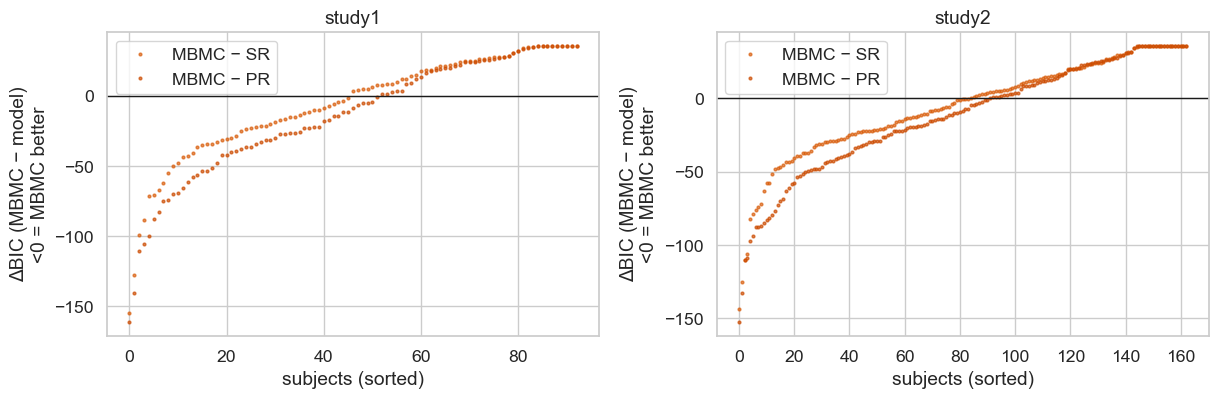

study1: best-fit model counts (by BIC) → {'MBMC': 44, 'CB': 21, 'PR': 14, 'SR': 14}
study2: best-fit model counts (by BIC) → {'MBMC': 79, 'CB': 37, 'SR': 26, 'PR': 21}


In [6]:
fig, axes = plt.subplots(1, len(STUDIES), figsize=(6.2*len(STUDIES), 4.2), squeeze=False)
for j, st in enumerate(STUDIES):
    ax = axes[0][j]
    if st not in data: ax.set_visible(False); continue
    f, _, _ = data[st]
    piv = f.pivot_table(index='sub', columns='model', values='bic')
    for m, c in [('SR', PALETTE['SR']), ('PR', PALETTE['PR'])]:
        if m in piv and 'MBMC' in piv:
            d = (piv['MBMC'] - piv[m]).sort_values().values   # <0 => MBMC better
            ax.plot(np.arange(len(d)), d, '.', ms=4, color=c, label=f'MBMC − {m}', alpha=0.7)
    ax.axhline(0, color='k', lw=1)
    ax.set_title(st); ax.set_xlabel('subjects (sorted)')
    ax.set_ylabel('ΔBIC (MBMC − model)\n<0 = MBMC better'); ax.legend()
plt.tight_layout(); plt.savefig('cbm_persubject_BIC.png', dpi=160, bbox_inches='tight'); plt.show()
# fraction of subjects best-fit by MBMC
for st in STUDIES:
    if st not in data: continue
    f = data[st][0]
    best = f.loc[f.groupby('sub')['bic'].idxmin(), ['sub','model']]
    vc = best['model'].value_counts()
    print(f'{st}: best-fit model counts (by BIC) →', vc.to_dict())

## 6. Fitted parameter distributions — winning model (MBMC)

Group distributions (median + IQR) of each MBMC parameter, back-transformed to
the native space. (Reviewer 2 minor: *"provide information about the fitted
parameter distributions for the winning model."*)

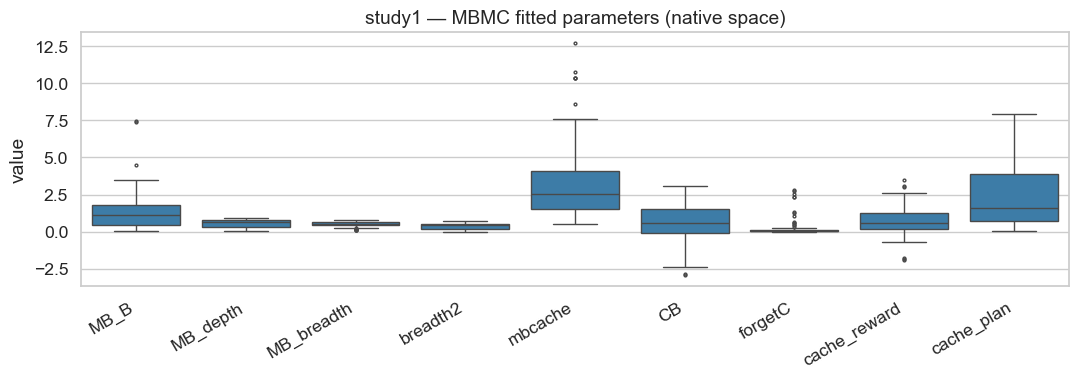

study1 MBMC median [IQR]:
   MB_B             1.099  [0.478, 1.829]
   MB_depth         0.620  [0.339, 0.771]
   MB_breadth       0.515  [0.485, 0.639]
   breadth2         0.458  [0.164, 0.500]
   mbcache          2.571  [1.535, 4.115]
   CB               0.583  [-0.064, 1.541]
   forgetC          0.069  [0.029, 0.132]
   cache_reward     0.570  [0.208, 1.251]
   cache_plan       1.588  [0.711, 3.894]


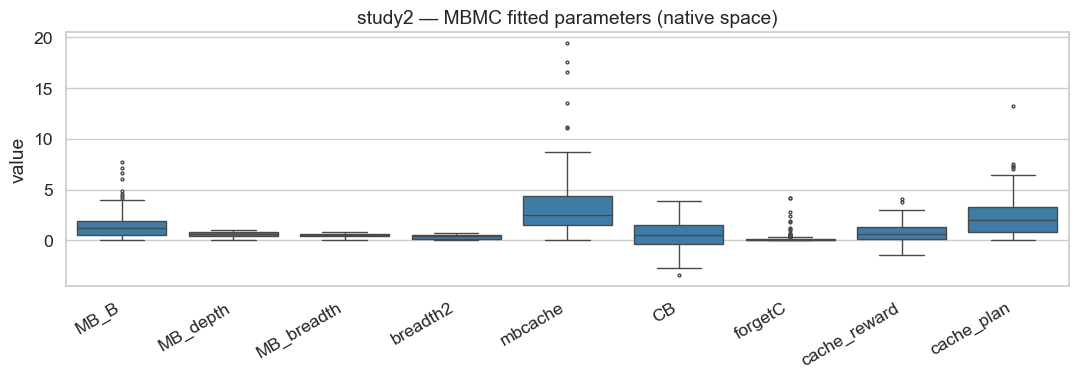

study2 MBMC median [IQR]:
   MB_B             1.237  [0.514, 1.911]
   MB_depth         0.655  [0.438, 0.808]
   MB_breadth       0.503  [0.375, 0.614]
   breadth2         0.401  [0.125, 0.497]
   mbcache          2.458  [1.495, 4.376]
   CB               0.534  [-0.366, 1.462]
   forgetC          0.069  [0.033, 0.140]
   cache_reward     0.575  [0.175, 1.296]
   cache_plan       1.987  [0.806, 3.285]


In [7]:
def native_params(study, name):
    '''return DataFrame of per-subject native parameters for a model.'''
    npy = os.path.join(RES, f'map_params_{study}_{name}.npy')       # fast MAP run
    pkl = os.path.join(RES, f'lap_{study}_{name}.pkl')              # CBM Laplace run
    if os.path.exists(npy):
        raw = np.asarray(np.load(npy))               # N x d (unconstrained)
    elif os.path.exists(pkl):
        raw = np.asarray(pickle.load(open(pkl, 'rb')).output.parameters)
    else:
        raise FileNotFoundError(name)
    types = MODELS[name]['types']; pnames = MODELS[name]['params']
    nat = np.array([M._transform(r, types) for r in raw])
    return pd.DataFrame(nat, columns=pnames)

for st in STUDIES:
    if st not in data: continue
    try:
        P = native_params(st, 'MBMC')
    except FileNotFoundError:
        continue
    fig, ax = plt.subplots(figsize=(11, 4))
    sns.boxplot(data=P, ax=ax, color='#2c7fb8', fliersize=2)
    ax.set_title(f'{st} — MBMC fitted parameters (native space)')
    ax.set_ylabel('value'); plt.xticks(rotation=30, ha='right')
    plt.tight_layout(); plt.savefig(f'cbm_MBMC_params_{st}.png', dpi=160, bbox_inches='tight'); plt.show()
    print(f'{st} MBMC median [IQR]:')
    for c in P.columns:
        q = P[c].quantile([.25,.5,.75]).values
        print(f'   {c:13s} {q[1]:8.3f}  [{q[0]:.3f}, {q[2]:.3f}]')

## 7. Fitted parameter distributions — SR and PR controllers

For completeness, the offline controllers' fitted parameters (β value-weight, γ
representation discount, CB control bias, κ_R relinquish-reward weight).

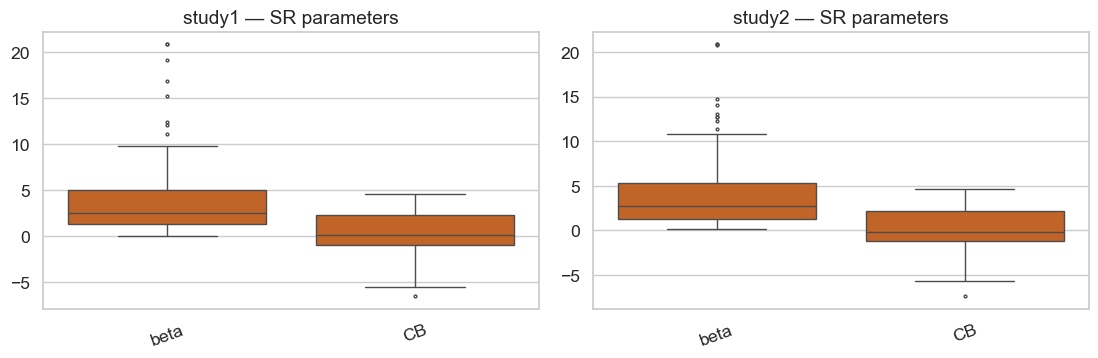

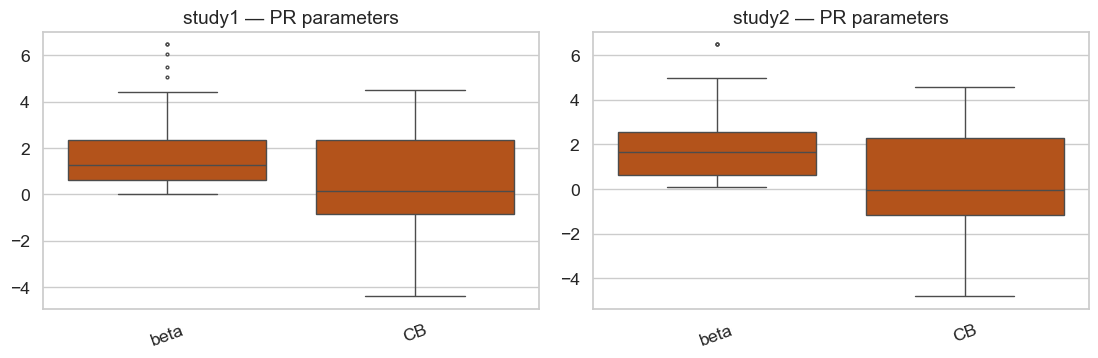

In [8]:
for name in ['SR', 'PR']:
    fig, axes = plt.subplots(1, len(STUDIES), figsize=(5.6*len(STUDIES), 3.8), squeeze=False)
    for j, st in enumerate(STUDIES):
        ax = axes[0][j]
        try:
            P = native_params(st, name)
        except FileNotFoundError:
            ax.set_visible(False); continue
        sns.boxplot(data=P, ax=ax, color=PALETTE[name], fliersize=2)
        ax.set_title(f'{st} — {name} parameters'); plt.setp(ax.get_xticklabels(), rotation=20)
    plt.tight_layout(); plt.savefig(f'cbm_{name}_params.png', dpi=160, bbox_inches='tight'); plt.show()

## 8. Summary for the response letter

The cell below assembles the key ΔBIC / Δlog-evidence numbers (and HBI
exceedance, if available) into one table — the SR/PR-vs-MBMC comparison the
reviewer asked for, in both studies.

In [9]:
out = []
for st in STUDIES:
    if st not in data: continue
    f, g, h = data[st]
    g = g.set_index('model')
    for m in ['MBMC', 'SR', 'PR', 'CB']:
        if m not in g.index: continue
        row = dict(study=st, model=m,
                   dBIC_vs_MBMC=round(g.loc[m,'delta_BIC_vs_MBMC'],1),
                   dLogEvidence_vs_MBMC=round(g.loc[m,'delta_LME_vs_MBMC'],1))
        if h is not None and m in h['models']:
            row['HBI_freq'] = round(float(np.asarray(h['model_frequency'])[h['models'].index(m)]),3)
            row['HBI_PXP']  = round(float(np.asarray(h['protected_exceedance_prob'])[h['models'].index(m)]),3)
        out.append(row)
summary = pd.DataFrame(out).sort_values(['study','model'])
summary.to_csv('cbm_response_summary.csv', index=False)
summary

,study,model,dBIC_vs_MBMC,dLogEvidence_vs_MBMC
3,study1,CB,5253.4,-4558.5
0,study1,MBMC,0.0,0.0
2,study1,PR,1348.7,-2364.7
1,study1,SR,589.7,-1985.2
7,study2,CB,9532.7,-8152.2
4,study2,MBMC,0.0,0.0
6,study2,PR,2103.0,-4014.1
5,study2,SR,1044.3,-3484.7
